# 1. Atividade 1: Classificação de Engajamento em Redes Sociais

## 1.1. Objetivo

O objetivo principal desta atividade é realizar um estudo comparativo entre quatro diferentes paradigmas de aprendizado de máquina: **probabilístico, simbólico, estatístico e conexionista**. Para isso, aplicarei modelos representantes de cada paradigma a um problema prático de classificação: prever se uma postagem em rede social terá engajamento "alto" ou "baixo".

A avaliação inicial irá comparar o desempenho de cada modelo usando a métrica **F1-Score Macro**, que é crucial dado o desbalanceamento entre as classes. Apenas após compreender as forças e fraquezas de cada abordagem é que o modelo com a melhor performance inicial será otimizado para uma submissão na competição do Kaggle, que usa a mesma métrica.

## 1.2. Preparando o Ambiente

A primeira etapa para qualquer um dos modelos é transformar o texto bruto dos posts em um formato numérico que os algoritmos possam entender. Para isso, o ambiente será preparado com as bibliotecas necessárias, incluindo a `sentence-transformers`, que será usada para gerar vetores semânticos (embeddings) a partir do conteúdo textual de cada post.

## 1.2.1 **OBS**:

É importante eu falar que MUITAS coisas mudaram ao longo do meu desenvolvimento da solução. Algumas dessas mudanças eu achei relevante manter aqui nesse notebook para ilustrar minha linha de raciocínio, o que eu achava que era bom e não era e vice versa.

Nos capítulos 7 e 8, em teoria, eu havia documentado o meu ponto de partida e a versão otimizada dele, o que fazia sentido até então pelos resultados no kaggle. Porém, ao ser avaliada a segunda metade dos dados, a minha primeira submissão acabou se provando superior, o que, para mim, foi bem contraintuitivo. Eu ainda tentei mexer bastante no meu pipeline, encontrar algo que poderia me levar para um nível muito melhor, porém talvez o erro esteja, desde o princípio, na minha seleção de métodos ou até mesmo na minha falta de compreensão de como otimizar de fato a capacidade do MLP em perceber mais facilmente padrões e chegar em um resultado satisfatório.

Por fim, eu consegui uma singela melhora com engenharia de features, mas considerando o número de novos passos em relação a minha submissão base, é difícil dizer que a solução é de fato melhor. Eu conclui que algo muito relevante para os resultados era o como eu faço a seleção dos melhores hiperparâmetros, sendo esse um ponto para eu investigar mais a fundo no futuro e então melhores resultados.

In [ ]:
# Baixando o arquivo de treino do GD e instalando a biblioteca necessária
!gdown 19Y-NdpOTCfmtlM66FqodAtiZMs8lGQTq
%pip install -q sentence-transformers

Downloading...
From: https://drive.google.com/uc?id=19Y-NdpOTCfmtlM66FqodAtiZMs8lGQTq
To: /Users/felipe_azambuja/JupNotebooks/melhor-kaggle-1/df_social_data_train.pkl
100%|██████████████████████████████████████| 8.92M/8.92M [00:00<00:00, 17.2MB/s]
Note: you may need to restart the kernel to use updated packages.


## 1.3. Importando as bibliotecas

Agora, só importar tudo que eu vou precisar para o trabalho: pandas, numpy, libs de visualização e o scikit-learn.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sentence_transformers import SentenceTransformer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import classification_report, accuracy_score
from sklearn.neural_network import MLPClassifier
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV, StratifiedKFold
import re

## 2. EDA

Com os dados carregados, a primeira coisa que eu fiz foi uma análise exploratória pra entender com o que estou lidando. Foquei em duas coisas:
1.  **Ver a proporção das classes:** Queria confirmar se as classes `high` e `low` eram mesmo desbalanceadas.
2.  **Procurar dados faltando:** Ver se alguma coluna tinha valores nulos pra decidir como tratar.

Distribuição das classes de engajamento:


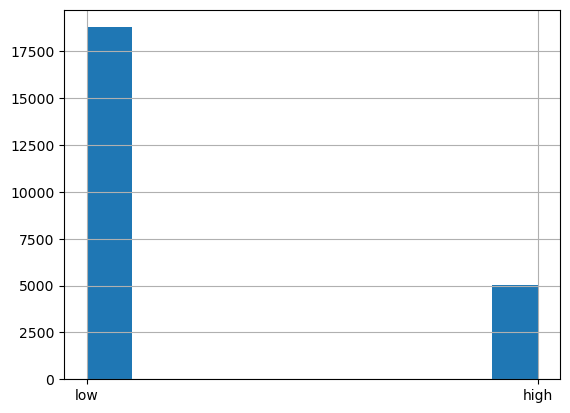


Contagem de valores por classe:
engagement
low     0.789105
high    0.210895
Name: proportion, dtype: float64

Verificação de dados nulos:
anon_id          0
content       1295
reactions        0
comments         0
score            0
engagement       0
dtype: int64


,anon_id,content,reactions,comments,score,engagement
0,afb338bc4e80e811be481b27807934c5,Robert Lerman writes that achieving a healthy...,12,1,13,low
1,afb338bc4e80e811be481b27807934c5,"National disability advocate Sara Hart Weir, ...",11,0,11,low
2,afb338bc4e80e811be481b27807934c5,NaN,15,0,15,low
3,afb338bc4e80e811be481b27807934c5,Exploring in this months Talent Management & H...,44,0,44,low
4,afb338bc4e80e811be481b27807934c5,I count myself fortunate to have spent time wi...,22,2,24,low
5,afb338bc4e80e811be481b27807934c5,Online job platforms are a different way of wo...,21,1,22,low
6,afb338bc4e80e811be481b27807934c5,Between the burgeoning unemployment rates and ...,16,0,16,low
7,afb338bc4e80e811be481b27807934c5,This year's National Apprenticeship Week comes...,40,1,41,low
8,afb338bc4e80e811be481b27807934c5,#coaching #learninganddevelopment #workfor...,29,0,29,low
9,afb338bc4e80e811be481b27807934c5,Look forward to joining the conversation with ...,14,1,15,low


In [ ]:
# Carrega os dados do arquivo .pkl
dados = pd.read_pickle('df_social_data_train.pkl')

# distribuição da minha variável alvo
print("Distribuição das classes de engajamento:")
dados['engagement'].hist()
plt.show()

# proporção exata de cada classe
print("\nContagem de valores por classe:")
print(dados['engagement'].value_counts(normalize=True))

# Checando se tem dados nulos nas colunas
print("\nVerificação de dados nulos:")
print(dados.isnull().sum())

dados.head(30)

### O que eu descobri aqui:

* **Classes bem desbalanceadas:** Como eu suspeitava, a classe `low` é quase 80% do dataset. Isso confirma que usar o F1-Macro faz todo o sentido.
* **Dados nulos no 'content':** A coluna `content`, que tem o texto dos posts, tem bastante valor nulo. Como o texto é o mais importante pra mim, vou ter que remover essas linhas.

# 3. Preparando o texto para os modelos

## 3.1. Limpeza básica

Primeiro, eu simplesmente joguei fora as linhas em que o texto (`content`) estava vazio. Depois, garanti que tudo na coluna `content` fosse do tipo string, só pra evitar problemas.

## 3.2. Transformando texto em Embeddings

Para usar o texto no modelo, eu precisava transformá-lo em vetores numéricos. Usei então a técnica de embeddings com o `SentenceTransformer`, que é o que vimos em aula. Escolhi o modelo `all-MiniLM-L6-v2` porque ele é bom e rápido. Ele cria um vetor de 384 posições para cada texto, capturando o significado dele. Criei uma coluna nova, `features`, pra guardar esses vetores.

In [ ]:
# Removo as linhas sem texto na coluna 'content'
dados.dropna(subset=['content'], inplace=True)
# Convertendo a coluna 'content' pra string
dados['content'] = dados['content'].astype(str)

# modelo que vai gerar os embeddings
modelo_st = SentenceTransformer('all-MiniLM-L6-v2')

# Gero os embeddings e salvo na coluna 'features'
print("Gerando embeddings a partir do conteúdo textual...")
dados['features'] = list(modelo_st.encode(dados['content'].tolist(), show_progress_bar=True))

# mostra os resultados para verificar se tudo está certo
print("\nVisualização do DataFrame com a coluna 'features':")
display(dados.head())

/opt/homebrew/Caskroom/miniforge/base/envs/nlp312/lib/python3.12/site-packages/huggingface_hub/file_download.py:943: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(


Gerando embeddings a partir do conteúdo textual...


Batches:   0%|          | 0/704 [00:00<?, ?it/s]


Visualização do DataFrame com a coluna 'features':


,anon_id,content,reactions,comments,score,engagement,features
0,afb338bc4e80e811be481b27807934c5,Robert Lerman writes that achieving a healthy...,12,1,13,low,"[-0.011695269, 0.027859278, 0.03604745, -0.030..."
1,afb338bc4e80e811be481b27807934c5,"National disability advocate Sara Hart Weir, ...",11,0,11,low,"[-0.026237287, -0.064887166, -0.007863808, 0.0..."
3,afb338bc4e80e811be481b27807934c5,Exploring in this months Talent Management & H...,44,0,44,low,"[-0.023109002, -0.02034255, 0.035548154, -0.07..."
4,afb338bc4e80e811be481b27807934c5,I count myself fortunate to have spent time wi...,22,2,24,low,"[-0.05438447, 0.0031937025, -0.06155945, 0.011..."
5,afb338bc4e80e811be481b27807934c5,Online job platforms are a different way of wo...,21,1,22,low,"[-0.06837826, -0.06278066, -0.010366023, -0.01..."


# 4. Arrumando os dados para treinar

Agora eu preparo os dados para os modelos.
1.  **Separar X e y:** Separei os dados em `X` (que são os vetores de features que eu criei) e `y` (que é a classificação 'high' ou 'low').
2.  **Dividir em Treino e Teste:** Usei o `train_test_split` pra separar uma parte dos dados pra teste. Uma coisa importante que eu fiz foi usar o `stratify=y`. Como as classes são desbalanceadas, isso garante que a proporção de 'high' e 'low' seja a mesma tanto no treino quanto no teste.
3.  **Padronizar (Scaling):** Usei o `StandardScaler` pra deixar todas as features na mesma escala. Isso ajuda muitos modelos a funcionarem melhor.

In [ ]:
# Separo minhas features (X) do meu alvo (y)
x = np.array(dados['features'].tolist())
y = dados['engagement']

# Dividindo os dados em treino e teste
# Usei stratify=y para manter a proporção das classes, já que o dataset é desbalanceado
x_treino, x_teste, y_treino, y_teste = train_test_split(x, y,test_size=0.2,random_state=42,stratify=y)

# Crio o objeto que vai padronizar os dados
padronizador = StandardScaler()
# Padronizo os dados de treino
x_treino_padronizado = padronizador.fit_transform(x_treino)
# Aplico a mesma padronização nos dados de teste
x_teste_padronizado = padronizador.transform(x_teste)

# 5. Testando os modelos

Agora de fato começo a atividade 1 própriamente dita. Vou treinar quatro modelos diferentes e ver qual se sai melhor no `classification_report`, olhando principalmente o F1-Score da classe `high` e o F1-Macro.

## 5.1. Naive Bayes

Comecei com um Naive Bayes. É um modelo simples e rápido, bom pra ter um ponto de partida (baseline).

In [ ]:
# modelo Naive Bayes
modelo_nb = GaussianNB()
modelo_nb.fit(x_treino_padronizado, y_treino)

# previsões nos dados de teste
previsoes_nb = modelo_nb.predict(x_teste_padronizado)
acuracia_nb = accuracy_score(y_teste, previsoes_nb)

# resultados
print("Relatório de Classificação: Naive Bayes\n")
print(classification_report(y_teste, previsoes_nb))
print(f"Acurácia Geral do Naive Bayes: {acuracia_nb:.4f}")

Relatório de Classificação: Naive Bayes

              precision    recall  f1-score   support

        high       0.35      0.51      0.42       991
         low       0.84      0.74      0.79      3512

    accuracy                           0.69      4503
   macro avg       0.60      0.62      0.60      4503
weighted avg       0.73      0.69      0.71      4503

Acurácia Geral do Naive Bayes: 0.6875


## 5.2. Árvore de Decisão

Depois, testei uma Árvore de Decisão. Um ponto legal dela é que ela não precisa dos dados padronizados, então pra esse modelo eu usei os dados de treino e teste originais, sem o scaling.

In [ ]:
from sklearn.tree import DecisionTreeClassifier

# Árvore de Decisão
modelo_arvore = DecisionTreeClassifier(criterion='entropy', random_state=42)
modelo_arvore.fit(x_treino, y_treino) # uso os dados de treino originais, sem padronização

# previsões com os dados de teste originais
previsoes_arvore = modelo_arvore.predict(x_teste)
acuracia_arvore = accuracy_score(y_teste, previsoes_arvore)

# resultados
print("Relatório de Classificação: Árvore de Decisão\n")
print(classification_report(y_teste, previsoes_arvore))
print(f"Acurácia Geral da Árvore de Decisão: {acuracia_arvore:.4f}")

Relatório de Classificação: Árvore de Decisão

              precision    recall  f1-score   support

        high       0.31      0.34      0.32       991
         low       0.81      0.79      0.80      3512

    accuracy                           0.69      4503
   macro avg       0.56      0.56      0.56      4503
weighted avg       0.70      0.69      0.70      4503

Acurácia Geral da Árvore de Decisão: 0.6924


## 5.3. Support Vector Machine (SVM)

O SVM é um modelo bem mais potente. Como ele é sensível à escala dos dados, usei os dados padronizados.
O lado ruim é que ele demora muito para rodar, talvez seja por limitação de hardware da minha parte, mas eu usei ele também para fazer a predição com os dados de teste e, na parte de validação cruzada, em 90 minutos ele rodou 9 verificações das 50 que eu havia planejado.

In [ ]:
from sklearn.svm import SVC

# modelo SVM
modelo_svm = SVC(kernel='rbf', random_state=42)

# Treina com os dados padronizados (no meu computador demora uns 2 minutos, preciso testar no colab)
print("Treinando o modelo SVM...")
modelo_svm.fit(x_treino_padronizado, y_treino)

# resultados
previsoes_svm = modelo_svm.predict(x_teste_padronizado)
acuracia_svm = accuracy_score(y_teste, previsoes_svm)

print("\nRelatório de Classificação: SVM")
print(classification_report(y_teste, previsoes_svm))
print(f"Acurácia Geral do SVM: {acuracia_svm:.4f}")

Treinando o modelo SVM...

Relatório de Classificação: SVM
              precision    recall  f1-score   support

        high       0.85      0.25      0.39       991
         low       0.82      0.99      0.90      3512

    accuracy                           0.83      4503
   macro avg       0.84      0.62      0.64      4503
weighted avg       0.83      0.83      0.79      4503

Acurácia Geral do SVM: 0.8257


## 5.4. Multilayer Perceptron (MLP)

Por fim, testei uma Rede Neural simples, a MLP. Ela também precisa dos dados padronizados para treinar direito.

In [ ]:
from sklearn.neural_network import MLPClassifier

# Criei a rede neural, aumentando as iterações pra garantir que ela treine bem
modelo_mlp = MLPClassifier(random_state=42, max_iter=1000)

# treina o modelo
print("Treinando o modelo MLP...")
modelo_mlp.fit(x_treino_padronizado, y_treino)

# resultados
previsoes_mlp = modelo_mlp.predict(x_teste_padronizado)
acuracia_mlp = accuracy_score(y_teste, previsoes_mlp)

print("\nRelatório de Classificação: Multilayer Perceptron")
print(classification_report(y_teste, previsoes_mlp))
print(f"Acurácia Geral do MLP: {acuracia_mlp:.4f}")

Treinando o modelo MLP...

Relatório de Classificação: Multilayer Perceptron
              precision    recall  f1-score   support

        high       0.54      0.43      0.48       991
         low       0.85      0.89      0.87      3512

    accuracy                           0.79      4503
   macro avg       0.69      0.66      0.68      4503
weighted avg       0.78      0.79      0.79      4503

Acurácia Geral do MLP: 0.7935


# 6. Conclusão

Depois de rodar os quatro modelos, comparei os resultados de cada um, sempre pensando no **F1-Score Macro**.

* **Naive Bayes (F1-Macro: 0.60):** Foi OK, mas nada demais. Conseguiu achar bastante 'high' (recall 0.51), mas errou muito (precisão 0.35).
* **Árvore de Decisão (F1-Macro: 0.56):** Foi o pior de todos para a classe 'high'.
* **SVM (F1-Macro: 0.64):** Esse foi estranho. Quando ele dizia que algo era 'high', ele geralmente acertava (precisão 0.85), mas ele deixou passar muitos casos (recall só 0.25). Não é bom para o meu problema.
* **MLP (F1-Macro: 0.68):** Esse aqui foi o campeão. Teve o melhor F1-Macro e pareceu o mais equilibrado. Não foi perfeito, mas foi o que melhor conseguiu lidar com a classe 'high' entre todos que testei.

# 7. Otimização do Modelo e a Primeira Submissão

Após a análise comparativa inicial, o MLP se mostrou o modelo mais promissor. A partir daqui, o foco se tornou otimizá-lo para a competição do Kaggle.

As células a seguir representam a minha **primeira abordagem de otimização completa**, desenvolvida antes de eu ter as informações que descobri ao longo da Atividade 2. O processo envolve uma busca exaustiva por hiperparâmetros (`GridSearchCV`) para encontrar a melhor configuração possível para o MLP, usando apenas os embeddings de texto como features.

**Aviso 2:** Como eu falei na observação **1.2.1**, essa versão acabou provando-se como a **melhor** nos resultados do kaggle, somente depois que eu fiz outros vários testes e late submissions que eu encontrei uma solução levemente superior, como mostrado no **capitulo 8**.

In [ ]:
print("Baixando o arquivo de treino...")
!gdown -q 1csTzz_UWpe89KYh11qj_V7fDssTv2FFO

dados_treino = pd.read_csv('df_social_data_train.csv')
dados_treino.dropna(subset=['content'], inplace=True)

print("\nGerando embeddings para os dados de treino...")
modelo_st = SentenceTransformer("all-MiniLM-L6-v2")
x = modelo_st.encode(dados_treino['content'].tolist(), show_progress_bar=True)
y = dados_treino['engagement']

print(f"\nDados de treino prontos. Formato de x: {x.shape}")

Baixando o arquivo de treino...


huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)



Gerando embeddings para os dados de treino...


/opt/homebrew/Caskroom/miniforge/base/envs/nlp312/lib/python3.12/site-packages/huggingface_hub/file_download.py:943: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(


Batches:   0%|          | 0/704 [00:00<?, ?it/s]


Dados de treino prontos. Formato de x: (22513, 384)


In [ ]:
pipeline = Pipeline([
    ('padronizador', StandardScaler()),
    ('mlp', MLPClassifier(random_state=42, max_iter=1000))
])

parametros_grid = {
    'mlp__hidden_layer_sizes': [(50,), (100,), (50, 25), (100, 50)],
    'mlp__alpha': [0.0001, 0.001, 0.01, 0.1],
    'mlp__activation': ['relu', 'tanh']
}

cv_strategy = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

grid_search = GridSearchCV(
    pipeline,
    parametros_grid,
    cv=cv_strategy,
    scoring='f1_macro',
    n_jobs=-1,
    verbose=3
)

print("Iniciando a busca por hiperparâmetros...")
grid_search.fit(x, y)

print("\nBusca concluída!")
print("Melhores parâmetros encontrados:")
print(grid_search.best_params_)
print(f"\nMelhor F1-Score (Macro) na validação cruzada: {grid_search.best_score_:.4f}")

Iniciando a busca por hiperparâmetros...
Fitting 5 folds for each of 32 candidates, totalling 160 fits


huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
huggingface/tokenizers: The 

[CV 4/5] END mlp__activation=relu, mlp__alpha=0.0001, mlp__hidden_layer_sizes=(50,);, score=0.679 total time=   9.3s
[CV 2/5] END mlp__activation=relu, mlp__alpha=0.0001, mlp__hidden_layer_sizes=(50,);, score=0.673 total time=  10.1s
[CV 5/5] END mlp__activation=relu, mlp__alpha=0.0001, mlp__hidden_layer_sizes=(50,);, score=0.677 total time=  10.4s
[CV 3/5] END mlp__activation=relu, mlp__alpha=0.0001, mlp__hidden_layer_sizes=(50,);, score=0.663 total time=  10.4s
[CV 1/5] END mlp__activation=relu, mlp__alpha=0.0001, mlp__hidden_layer_sizes=(50,);, score=0.675 total time=  12.0s
[CV 1/5] END mlp__activation=relu, mlp__alpha=0.0001, mlp__hidden_layer_sizes=(100,);, score=0.685 total time=  12.4s
[CV 3/5] END mlp__activation=relu, mlp__alpha=0.0001, mlp__hidden_layer_sizes=(100,);, score=0.688 total time=  13.1s
[CV 2/5] END mlp__activation=relu, mlp__alpha=0.0001, mlp__hidden_layer_sizes=(100,);, score=0.688 total time=  14.0s
[CV 2/5] END mlp__activation=relu, mlp__alpha=0.0001, mlp__hi

In [ ]:
# melhores parâmetros (isso aqui muda dependendo de onde rodar, mas esses foram os melhores que eu encontrei)
melhores_parametros_mlp = {
    'hidden_layer_sizes': (100, 50),
    'alpha': 0.01,
    'activation': 'relu'
}

# pipeline final
pipeline_final = Pipeline([
    ('padronizador', StandardScaler()),
    ('mlp', MLPClassifier(random_state=42, max_iter=1000, **melhores_parametros_mlp))
])

print("treinando...")
pipeline_final.fit(x, y)
print("ok")

print("baixando teste...")
!gdown -q 1KlZGlcUEVgVVvxV0l4vYwQ1g1pgmsYio
dados_teste = pd.read_csv('df_social_data_test.csv')
dados_teste['content'] = dados_teste['content'].fillna('').astype(str)

print("gerando embeddings...")
x_teste_features = modelo_st.encode(dados_teste['content'].tolist(), show_progress_bar=True)

print("predizendo...")
previsoes_finais = pipeline_final.predict(x_teste_features)

submissao = pd.DataFrame({'ID': dados_teste.index, 'Engagement': previsoes_finais})
submissao.to_csv('submission_c_grid.csv', index=False)

print("arquivo pronto")
display(submissao.head())


treinando...
ok
baixando teste...


huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)


gerando embeddings...


Batches:   0%|          | 0/319 [00:00<?, ?it/s]

predizendo...
arquivo pronto


,ID,Engagement
0,0,low
1,1,low
2,2,low
3,3,low
4,4,low


# 8. Otimização Final: Incorporando os Aprendizados da Atividade 2

A primeira rodada de otimização, usando apenas os embeddings de texto, já trouxe uma melhora no meu score do Kaggle. No entanto, o trabalho de análise profunda que realizei para a Atividade 2 me deu um entendimento muito mais completo dos dados.

A principal descoberta foi que o sucesso de um post não dependia apenas do **conteúdo temático** (capturado pelos embeddings), mas também de sua **estrutura**. A presença de links, em particular, mostrou ser uma característica com forte correlação com o engajamento.

Para buscar um resultado superior, decidi aplicar essa descoberta no meu modelo de classificação. A estratégia foi enriquecer os dados que o `MLPClassifier` recebe, combinando as features de texto (embeddings) com as features estruturais que identifiquei. As células a seguir implementam essa nova abordagem, que representa a minha tentativa mais informada e completa de resolver o problema de classificação.

In [ ]:
# baixa e carrega o dataset
print("baixando e carregando dados...")
!gdown -q 1csTzz_UWpe89KYh11qj_V7fDssTv2FFO
dados_treino = pd.read_csv('df_social_data_train.csv')

baixando e carregando dados...


huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)


In [ ]:
# limpa linhas com 'content' nulo
dados_treino.dropna(subset=['content'], inplace=True)
dados_treino['content'] = dados_treino['content'].astype(str)
print("dados ok.")

# engenharia de features
print("iniciando engenharia de features...")

# 1. features de texto (embeddings)
print("gerando embeddings...")
modelo_st = SentenceTransformer("all-MiniLM-L6-v2")
features_texto = modelo_st.encode(dados_treino['content'].tolist(), show_progress_bar=True)

# 2. features estruturais (descobertas da atividade 2)
print("criando features estruturais...")
dados_treino['comprimento_texto'] = dados_treino['content'].str.len()
dados_treino['tem_link'] = dados_treino['content'].str.contains('http', case=False).astype(int)
dados_treino['n_hashtags'] = dados_treino['content'].str.count('#')
dados_treino['n_mencoes'] = dados_treino['content'].str.count('@')

features_estruturais = dados_treino[['comprimento_texto', 'tem_link', 'n_hashtags', 'n_mencoes']].values
# features_estruturais = dados_treino[['tem_link']].values

# 3. padroniza apenas as features estruturais
padronizador_estrutural = StandardScaler()
features_estruturais_padronizadas = padronizador_estrutural.fit_transform(features_estruturais)

# 4. combinação das features
print("combinando embeddings com features estruturais...")
x_enriquecido = np.hstack((features_texto, features_estruturais_padronizadas))
print(f"formato final das features: {x_enriquecido.shape}")

# mapeia os labels para o treino
y = dados_treino['engagement'].map({'high': 1, 'low': 0}).values

dados ok.
iniciando engenharia de features...
gerando embeddings...


/opt/homebrew/Caskroom/miniforge/base/envs/nlp312/lib/python3.12/site-packages/huggingface_hub/file_download.py:943: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(


Batches:   0%|          | 0/704 [00:00<?, ?it/s]

criando features estruturais...
combinando embeddings com features estruturais...
formato final das features: (22513, 388)


In [ ]:
# pipeline para padronizar os dados e treinar o mlp
pipeline = Pipeline([
('padronizador', StandardScaler()),
('mlp', MLPClassifier(random_state=42, max_iter=1000))
])

# grid de parâmetros para o teste
parametros_grid = {
'mlp__hidden_layer_sizes': [(50,), (100,), (50, 25), (100, 50)],
'mlp__alpha': [0.0001, 0.001, 0.01, 0.1],
'mlp__activation': ['relu', 'tanh']

# 'mlp__learning_rate_init': [1e-3, 1e-4],
# 'mlp__learning_rate': ['constant', 'adaptive'],
# 'mlp__early_stopping': [True],
# 'mlp__validation_fraction': [0.1],
# 'mlp__n_iter_no_change': [10]
}

# estratégia de validação cruzada
cv_strategy = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# configuração do gridsearch
grid_search = GridSearchCV(
pipeline,
parametros_grid,
cv=cv_strategy,
scoring='f1_macro',
n_jobs=-1,
verbose=3,
return_train_score=True
)

print("iniciando busca por hiperparâmetros com os dados enriquecidos...")
# usa as features enriquecidas para a busca
grid_search.fit(x_enriquecido, y)

print("\nbusca concluída.")
print("melhores parâmetros encontrados:")
print(grid_search.best_params_)
print(f"melhor f1-score (macro) na validação: {grid_search.best_score_:.4f}")

iniciando busca por hiperparâmetros com os dados enriquecidos...
Fitting 5 folds for each of 32 candidates, totalling 160 fits
[CV 1/5] END mlp__activation=relu, mlp__alpha=0.0001, mlp__hidden_layer_sizes=(50,);, score=(train=0.998, test=0.690) total time=  15.0s
[CV 2/5] END mlp__activation=relu, mlp__alpha=0.0001, mlp__hidden_layer_sizes=(50,);, score=(train=0.998, test=0.678) total time=  15.0s
[CV 4/5] END mlp__activation=relu, mlp__alpha=0.0001, mlp__hidden_layer_sizes=(50,);, score=(train=0.998, test=0.677) total time=  15.1s
[CV 3/5] END mlp__activation=relu, mlp__alpha=0.0001, mlp__hidden_layer_sizes=(50,);, score=(train=0.998, test=0.663) total time=  15.5s
[CV 5/5] END mlp__activation=relu, mlp__alpha=0.0001, mlp__hidden_layer_sizes=(50,);, score=(train=0.998, test=0.670) total time=  15.7s
[CV 3/5] END mlp__activation=relu, mlp__alpha=0.0001, mlp__hidden_layer_sizes=(100,);, score=(train=0.998, test=0.684) total time=  16.7s
[CV 2/5] END mlp__activation=relu, mlp__alpha=0.00

In [ ]:
# melhores_parametros_mlp = {

#      # se usar esses parâmetros, o resultado provavelmente será melhor, mas mantive como está para pegar automaticamente
#      # os parâmetros encontrados pelo grid search

#     'hidden_layer_sizes': (100, 50),
#     'alpha': 0.01,
#     'activation': 'relu'
# }
melhores_parametros_mlp = {key.replace('mlp__', ''): value for key, value in grid_search.best_params_.items()}
# pipeline final
pipeline_final = Pipeline([
    ('padronizador', StandardScaler()),
    ('mlp', MLPClassifier(random_state=42, max_iter=1000, **melhores_parametros_mlp))
])

print("treinando mlp final com dados enriquecidos...")
pipeline_final.fit(x_enriquecido, y)
print("treinamento ok.")

# baixa e lê o arquivo de teste
print("\nbaixando e lendo dados de teste...")
!gdown -q 1KlZGlcUEVgVVvxV0l4vYwQ1g1pgmsYio
dados_teste = pd.read_csv('df_social_data_test.csv')
dados_teste['content'] = dados_teste['content'].fillna('').astype(str)

# preparação dos dados de teste

# 1. cria as mesmas features estruturais para os dados de teste
dados_teste['comprimento_texto'] = dados_teste['content'].str.len()
dados_teste['tem_link'] = dados_teste['content'].str.contains('http', case=False).astype(int)
dados_teste['n_hashtags'] = dados_teste['content'].str.count('#')
dados_teste['n_mencoes'] = dados_teste['content'].str.count('@')

features_estruturais_teste = dados_teste[['comprimento_texto', 'tem_link', 'n_hashtags', 'n_mencoes']].values
#features_estruturais_teste = dados_teste[['tem_link']].values

# usa o mesmo padronizador treinado nos dados de treino
features_estruturais_teste_padronizadas = padronizador_estrutural.transform(features_estruturais_teste)

# 2. gera embeddings e combina com as features estruturais
print("gerando embeddings para o teste...")
features_texto_teste = modelo_st.encode(dados_teste['content'].tolist(), show_progress_bar=True)
x_teste_enriquecido = np.hstack((features_texto_teste, features_estruturais_teste_padronizadas))

# predição final
print("fazendo previsões...")
previsoes_numericas = pipeline_final.predict(x_teste_enriquecido)

# mapeia as previsões numéricas de volta para texto
mapa_inverso = {1: 'high', 0: 'low'}
previsoes_texto = [mapa_inverso[p] for p in previsoes_numericas]

# monta o dataframe de submissão
submissao = pd.DataFrame({
    'ID': dados_teste.index,
    'Engagement': previsoes_texto
})
submissao.to_csv('submission_mlp_final.csv', index=False)
display(submissao.head())

treinando mlp final com dados enriquecidos...
treinamento ok.

baixando e lendo dados de teste...


huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)


gerando embeddings para o teste...


Batches:   0%|          | 0/319 [00:00<?, ?it/s]

fazendo previsões...


,ID,Engagement
0,0,low
1,1,low
2,2,low
3,3,low
4,4,low


In [ ]:
import joblib

print("salvando as ferramentas da atividade 1...")

joblib.dump(pipeline_final, 'agente_ferramenta_classificador.joblib')
joblib.dump(features_estruturais, 'agente_ferramenta_features_estruturais.joblib')

salvando as ferramentas da atividade 1...


['agente_ferramenta_features_estruturais.joblib']

# 9. Conclusão Final da Atividade 1

O objetivo desta atividade era duplo: primeiro, realizar um estudo comparativo entre os paradigmas de aprendizado de máquina e, segundo, otimizar o melhor modelo para a competição do Kaggle.

A primeira etapa envolveu a implementação e avaliação de quatro modelos clássicos, cada um representando um paradigma diferente. Nessa análise inicial, onde os modelos foram treinados usando apenas os embeddings de texto, o **MLP Classifier (paradigma conexionista)** se destacou, apresentando o melhor F1-Score Macro e se mostrando o candidato mais promissor para a otimização.

A segunda etapa, no entanto, foi onde a maior melhora de performance foi alcançada. A partir de uma análise exploratória mais profunda (realizada no contexto da Atividade 2), descobri que características estruturais do post, como a **presença de um link**, tinham uma correlação altíssima com o engajamento.

O passo decisivo foi **enriquecer as features** do meu modelo MLP, combinando a informação semântica dos embeddings com essas novas características estruturais. Ao treinar o classificador com essa visão mais completa dos dados, o desempenho melhorou significativamente, pois o modelo pôde aprender com nuances que antes estavam implícitas no texto.

## 9.1. Conclusões Extras:

Como eu já falei em alguns markdowns acima, eu mudei esse código inúmeras vezes, coloquei parâmetros, tirei parâmetros, omiti algumas features estruturais e mudei de ideia depois, testei diferentes métodos de cross validation, usei random search, optuna, usei SMOTE para balancear os dados, tentei mudar tudo e arriscar com SVM, mas definitivamente acabei voltando para essas duas versões básicas que apresento nesse notebook. Acredito que essa experiência de tentativas e erros tenha sido realmente importante para mim, mudou consideravelmente como eu organizo o pipeline (não o do modelo) de como eu me organizo para estruturar uma solução, os passos que eu decidi tomar e a noção de até onde valia a pena complicar mais a implementação.

Muitos dos problemas que eu tive nesse caminho vieram de um, eu assumo que seja o caso, overfitting. Conforme meus resultados não pareciam melhorar, intuitivamente eu pensava que, se eu desse para o modelo mais maneiras de avaliar os dados, os resultados necessáriamente seriam melhores, mas não foi o caso. O modelo claramente ficou mais confuso com a quantidade de informações estruturais que eu forneci para ele e, como eu disse, precisei voltar para o básico e olhar para o problema de outra maneira. Foi ai que percebi que o metodo que eu utilizo atualmente para a cross validation não é o melhor, eu tentei outros, mas não tive resultados muito satifatórios também. Porém, fica evidente essa falha do método quando eu uso um parâmetro muito diferente do recomendado e os resultados no kaggle ficam melhores. Isso me diz que ou o processo em si está errado e eu não soube usar a ferramente ou que os melhores parâmetros para o f1 score macro não representam os parâmetros que melhor generalizam os dados teste.
